In [ ]:
import pandas as pd
import numpy as np

In [ ]:
NE2 = pd.read_csv('NE2_semanal_mediana_con_ndvi_sin_nulos.csv')
NE3 = pd.read_csv('NE3_semanal_mediana_con_ndvi_sin_nulos.csv')

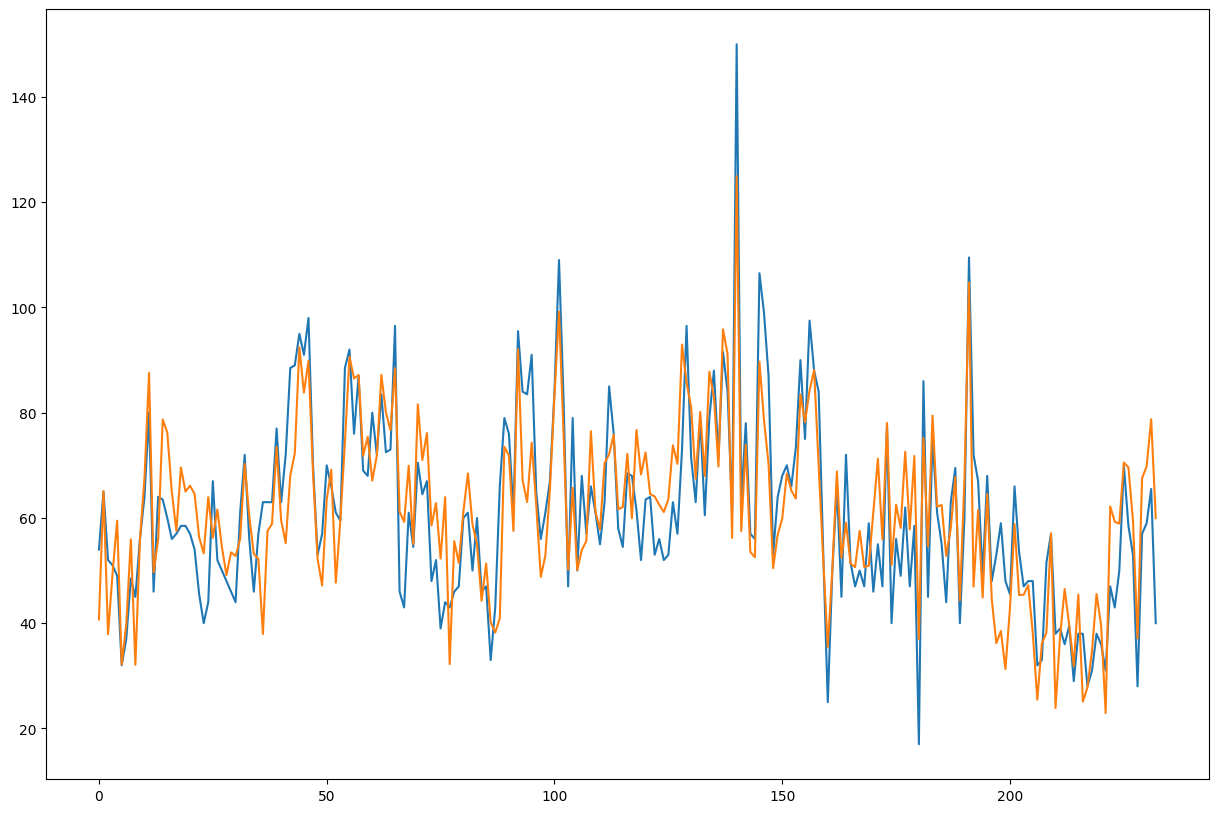

In [ ]:
# Desestacionalización

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

resultado_pm10 = seasonal_decompose(NE2['PM10'], model = 'add', period = 52)

NE2['PM10_des'] = NE2['PM10'] - resultado_pm10.seasonal

resultado_pm10 = seasonal_decompose(NE3['PM10'], model = 'add', period = 52)

NE3['PM10_des'] = NE3['PM10'] - resultado_pm10.seasonal


plt.figure(figsize = (15, 10))
plt.plot(NE2['PM10'], label='original')
plt.plot(NE2['PM10_des'], label='desestacionalizado')
plt.show()

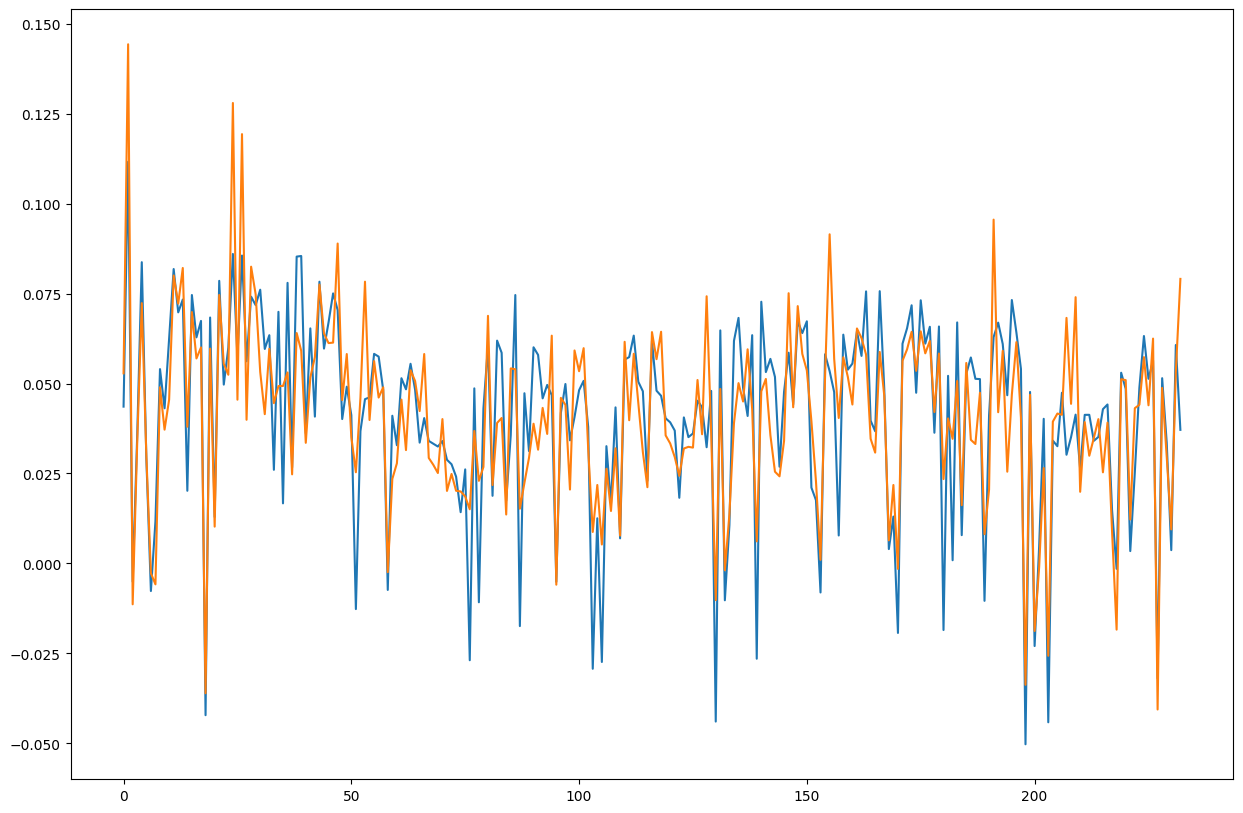

In [ ]:
resultado_nvdi = seasonal_decompose(NE2['ndvi_mediana'], model = 'add', period = 52)

NE2['ndvi_des'] = NE2['ndvi_mediana'] - resultado_nvdi.seasonal

resultado_nvdi = seasonal_decompose(NE3['ndvi_mediana'], model = 'add', period = 52)

NE3['ndvi_des'] = NE3['ndvi_mediana'] - resultado_nvdi.seasonal

plt.figure(figsize = (15, 10))
plt.plot(NE2['ndvi_mediana'], label='original')
plt.plot(NE2['ndvi_des'], label='desestacionalizado')
plt.show()

In [ ]:
NE2[['PM10','ndvi_mediana','PM10_des','ndvi_des']].corr()

,PM10,ndvi_mediana,PM10_des,ndvi_des
PM10,1.000000,0.213701,0.840125,0.176912
ndvi_mediana,0.213701,1.000000,0.199032,0.828946
PM10_des,0.840125,0.199032,1.000000,0.224906
ndvi_des,0.176912,0.828946,0.224906,1.000000


In [ ]:
NE3[['PM10','ndvi_mediana','PM10_des','ndvi_des']].corr()

,PM10,ndvi_mediana,PM10_des,ndvi_des
PM10,1.000000,0.033882,0.840602,-0.010880
ndvi_mediana,0.033882,1.000000,0.021087,0.830692
PM10_des,0.840602,0.021087,1.000000,-0.006727
ndvi_des,-0.010880,0.830692,-0.006727,1.000000


## Pruebas de correlación

Pearson y Spearman

In [ ]:
from scipy.stats import pearsonr, spearmanr

def resumen_correlacion(df, nombre, col_x='ndvi_des', col_y='PM10_des'):
    sub = df[[col_x, col_y]].dropna()
    r_p, p_p = pearsonr(sub[col_x], sub[col_y])
    r_s, p_s = spearmanr(sub[col_x], sub[col_y])
    print(f'--- {nombre} (n={len(sub)}) ---')
    print(f'Pearson  r = {r_p:.3f}  p = {p_p:.4f}')
    print(f'Spearman r = {r_s:.3f}  p = {p_s:.4f}')
    return {'estacion': nombre, 'n': len(sub), 'pearson_r': r_p, 'pearson_p': p_p,
            'spearman_r': r_s, 'spearman_p': p_s}

res_ne2 = resumen_correlacion(NE2, 'NE2')
res_ne3 = resumen_correlacion(NE3, 'NE3')


--- NE2 (n=233) ---
Pearson  r = 0.225  p = 0.0005
Spearman r = 0.214  p = 0.0010
--- NE3 (n=233) ---
Pearson  r = -0.007  p = 0.9186
Spearman r = 0.003  p = 0.9636


Boostrap

In [ ]:
import numpy as np

def block_bootstrap_corr(x, y, block_size=8, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(x); y = np.asarray(y)
    n = len(x)
    n_blocks = int(np.ceil(n / block_size))
    boot_r = np.empty(n_boot)
    for b in range(n_boot):
        starts = rng.integers(0, n - block_size, size=n_blocks)
        idx = np.concatenate([np.arange(s, s + block_size) for s in starts])[:n]
        boot_r[b] = np.corrcoef(x[idx], y[idx])[0, 1]
    return boot_r

for nombre, df in [('NE2', NE2), ('NE3', NE3)]:
    sub = df[['ndvi_des', 'PM10_des']].dropna()
    boot_r = block_bootstrap_corr(sub['ndvi_des'].values, sub['PM10_des'].values)
    ci_low, ci_high = np.percentile(boot_r, [2.5, 97.5])
    r_obs = np.corrcoef(sub['ndvi_des'], sub['PM10_des'])[0, 1]
    significativo = not (ci_low <= 0 <= ci_high)
    print(f'{nombre}: r={r_obs:.3f}  IC 95% bootstrap por bloques = [{ci_low:.3f}, {ci_high:.3f}]  '
          f'-> {"significativo" if significativo else "NO significativo (el IC incluye 0)"}')


NE2: r=0.225  IC 95% bootstrap por bloques = [0.112, 0.345]  -> significativo
NE3: r=-0.007  IC 95% bootstrap por bloques = [-0.171, 0.146]  -> NO significativo (el IC incluye 0)


Test de permutación para CCF completa

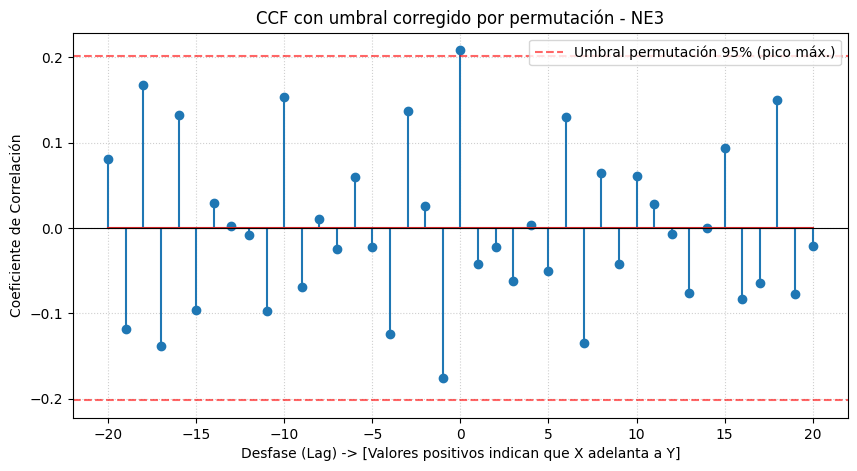

NE3: pico máx. observado = 0.208  |  p-value (patrón completo de la CCF) = 0.0355


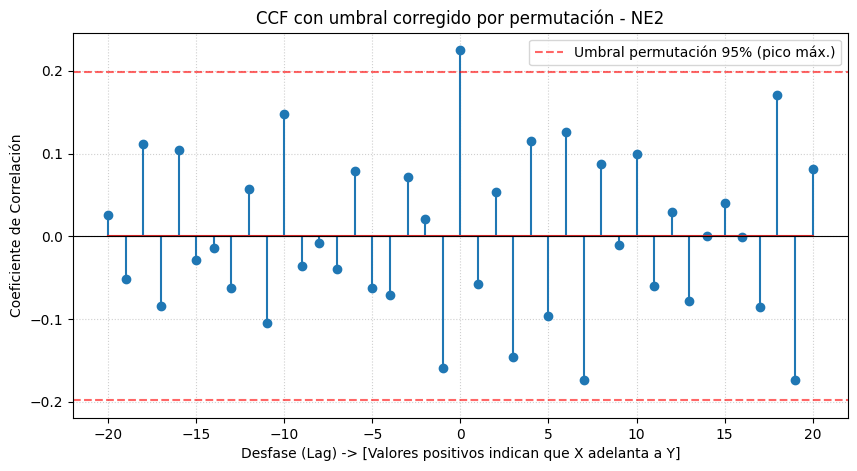

NE2: pico máx. observado = 0.225  |  p-value (patrón completo de la CCF) = 0.0105


In [ ]:
def ccf_bidireccional(x, y, max_lag=20):
    x = np.asarray(x); y = np.asarray(y)
    norm_x = (x - np.mean(x)) / (np.std(x) * len(x))
    norm_y = (y - np.mean(y)) / np.std(y)
    ccf_full = np.correlate(norm_x, norm_y, mode='full')
    mid = len(ccf_full) // 2
    return ccf_full[mid - max_lag: mid + max_lag + 1]

def permutation_test_ccf(x_raw, y_raw, max_lag=20, n_perm=2000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.diff(np.asarray(x_raw))
    y = np.diff(np.asarray(y_raw))
    lags = np.arange(-max_lag, max_lag + 1)

    ccf_obs = ccf_bidireccional(x, y, max_lag)
    stat_obs = np.max(np.abs(ccf_obs))  # estadístico resumen: pico máximo absoluto de la CCF

    stat_null = np.empty(n_perm)
    for i in range(n_perm):
        y_shuff = rng.permutation(y)
        ccf_null = ccf_bidireccional(x, y_shuff, max_lag)
        stat_null[i] = np.max(np.abs(ccf_null))

    p_value = (np.sum(stat_null >= stat_obs) + 1) / (n_perm + 1)
    return lags, ccf_obs, stat_obs, stat_null, p_value

for nombre, df in [('NE3', NE3), ('NE2', NE2)]:
    sub = df[['ndvi_des', 'PM10_des']].dropna()
    lags, ccf_obs, stat_obs, stat_null, p_value = permutation_test_ccf(
        sub['ndvi_des'], sub['PM10_des'])

    plt.figure(figsize=(10, 5))
    plt.stem(lags, ccf_obs)
    perm_band = np.percentile(stat_null, 95)
    plt.axhline(y=perm_band, color='r', linestyle='--', alpha=0.6,
                label=f'Umbral permutación 95% (pico máx.)')
    plt.axhline(y=-perm_band, color='r', linestyle='--', alpha=0.6)
    plt.axhline(y=0, color='black', linewidth=0.8)
    plt.title(f'CCF con umbral corregido por permutación - {nombre}')
    plt.xlabel('Desfase (Lag) -> [Valores positivos indican que X adelanta a Y]')
    plt.ylabel('Coeficiente de Correlación')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

    print(f'{nombre}: pico máx. observado = {stat_obs:.3f}  |  '
          f'p-value (patrón completo de la CCF) = {p_value:.4f}')


## Separación por estación

In [ ]:
def agregar_fecha_y_temporada(df):
    df = df.copy()
    df['fecha'] = pd.to_datetime(df['semana'])
    df['mes'] = df['fecha'].dt.month

    # Definición por calendario (ajustar meses según la zona de estudio)
    meses_humedos = [5, 6, 7, 8, 9, 10]
    df['temporada_calendario'] = np.where(df['mes'].isin(meses_humedos), 'humeda', 'seca')

    # Definición alternativa basada en precipitación observada (RAINF), por si se prefiere
    # no asumir un calendario fijo: por encima de la mediana de RAINF = húmeda
    mediana_rainf = df['RAINF'].median()
    df['temporada_rainf'] = np.where(df['RAINF'] >= mediana_rainf, 'humeda', 'seca')

    return df

NE2 = agregar_fecha_y_temporada(NE2)
NE3 = agregar_fecha_y_temporada(NE3)

print(NE2[['fecha', 'mes', 'temporada_calendario', 'temporada_rainf']].head())
print()
print('Conteo NE2 (calendario):', NE2['temporada_calendario'].value_counts().to_dict())
print('Conteo NE3 (calendario):', NE3['temporada_calendario'].value_counts().to_dict())


       fecha  mes temporada_calendario temporada_rainf
0 2021-01-04    1                 seca          humeda
1 2021-01-11    1                 seca          humeda
2 2021-01-18    1                 seca          humeda
3 2021-01-25    1                 seca          humeda
4 2021-02-01    2                 seca          humeda

Conteo NE2 (calendario): {'humeda': 118, 'seca': 115}
Conteo NE3 (calendario): {'humeda': 118, 'seca': 115}


In [ ]:
def correlacion_por_temporada(df, nombre, col_temporada='temporada_calendario',
                               col_x='ndvi_des', col_y='PM10_des'):
    resultados = []
    for temporada in ['seca', 'humeda']:
        sub = df.loc[df[col_temporada] == temporada, [col_x, col_y]].dropna()
        if len(sub) < 10:
            print(f'{nombre} - {temporada}: n={len(sub)} (muy pocos datos, se omite)')
            continue
        r_p, p_p = pearsonr(sub[col_x], sub[col_y])
        r_s, p_s = spearmanr(sub[col_x], sub[col_y])
        print(f'{nombre} - {temporada} (n={len(sub)}): '
              f'Pearson r={r_p:.3f} (p={p_p:.4f})  |  Spearman r={r_s:.3f} (p={p_s:.4f})')
        resultados.append({'estacion': nombre, 'temporada': temporada, 'n': len(sub),
                            'pearson_r': r_p, 'pearson_p': p_p,
                            'spearman_r': r_s, 'spearman_p': p_s})
    return resultados

print('=== Definición por calendario ===')
res_temporada = []
res_temporada += correlacion_por_temporada(NE2, 'NE2', 'temporada_calendario')
res_temporada += correlacion_por_temporada(NE3, 'NE3', 'temporada_calendario')

print()
print('=== Definición por RAINF (mediana) ===')
res_temporada += correlacion_por_temporada(NE2, 'NE2', 'temporada_rainf')
res_temporada += correlacion_por_temporada(NE3, 'NE3', 'temporada_rainf')

pd.DataFrame(res_temporada)


=== Definición por calendario ===
NE2 - seca (n=115): Pearson r=0.269 (p=0.0037)  |  Spearman r=0.262 (p=0.0046)
NE2 - humeda (n=118): Pearson r=0.175 (p=0.0581)  |  Spearman r=0.159 (p=0.0859)
NE3 - seca (n=115): Pearson r=0.092 (p=0.3290)  |  Spearman r=0.104 (p=0.2700)
NE3 - humeda (n=118): Pearson r=-0.066 (p=0.4777)  |  Spearman r=-0.027 (p=0.7753)

=== Definición por RAINF (mediana) ===
NE2 - seca: n=0 (muy pocos datos, se omite)
NE2 - humeda (n=233): Pearson r=0.225 (p=0.0005)  |  Spearman r=0.214 (p=0.0010)
NE3 - seca: n=0 (muy pocos datos, se omite)
NE3 - humeda (n=233): Pearson r=-0.007 (p=0.9186)  |  Spearman r=0.003 (p=0.9636)


,estacion,temporada,n,pearson_r,pearson_p,spearman_r,spearman_p
0,NE2,seca,115,0.268672,0.003693,0.262456,0.004602
1,NE2,humeda,118,0.174983,0.058064,0.158796,0.085885
2,NE3,seca,115,0.091842,0.328965,0.103709,0.270034
3,NE3,humeda,118,-0.065998,0.477663,-0.026550,0.775344
4,NE2,humeda,233,0.224906,0.000542,0.213690,0.001030
5,NE3,humeda,233,-0.006727,0.918647,0.003003,0.963634


## Con datos estacionalizados

In [ ]:
NE2_limpio = NE2[['PM10_des','ndvi_des','SR','RH','TOUT','PRS']]
NE2_limpio = NE2_limpio.dropna()

NE3_limpio = NE3[['PM10_des','ndvi_des','SR','RH','TOUT','PRS']]
NE3_limpio = NE3_limpio.dropna()

In [ ]:
# Desestacionalizar toda la base de datos

cols = ['SR','RH','TOUT','PRS']

for col in cols:
    resultado = seasonal_decompose(NE2_limpio[col], model = 'add', period = 52)
    NE2_limpio[f'{col}_des'] = NE2_limpio[col] - resultado.seasonal

for col in cols:
    resultado = seasonal_decompose(NE3[col], model = 'add', period = 52)
    NE3_limpio[f'{col}_des'] = NE3_limpio[col] - resultado.seasonal

In [ ]:
# quitar nulos
X = NE2_limpio[['ndvi_des','SR_des','RH_des','TOUT_des','PRS_des']]
y = NE2_limpio['PM10_des']

In [ ]:
# PLS estándar

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# Escalar las características
scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pls = PLSRegression(n_components=2)

pls.fit(X_train, y_train)

y_pred = pls.predict(X_test)
score = r2_score(y_test, y_pred)

print(f"R-squared (R2): {score:.4f}")


R-squared (R2): 0.3266


=== Importancia y Estructura de Variables (Ordenado por VIP) ===
Variable_Lag      VIP  Peso_W1*  Coeficiente
      RH_des 1.245714  0.666776    -6.035722
    TOUT_des 1.232952  0.109208    -6.436814
     PRS_des 0.878643  0.470494    -4.275604
    ndvi_des 0.847200 -0.449237     3.805229
      SR_des 0.662016  0.346851    -4.081494


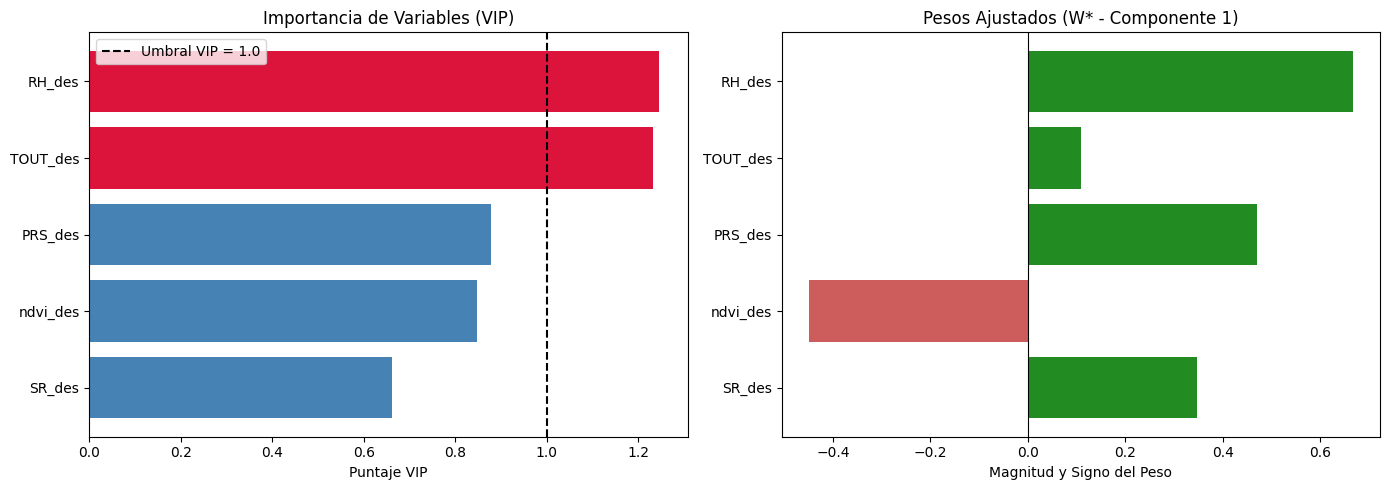

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calculate_vip(model):
    """
    Calcula el puntaje VIP (Variable Importance in Projection)
    para un objeto PLSRegression de scikit-learn.
    """
    t = model.x_scores_       # Puntuaciones de X
    w = model.x_weights_      # Pesos de X
    q = model.y_loadings_     # Cargas de Y

    p, h = w.shape            # p = número de variables, h = número de componentes
    vips = np.zeros(p)

    # Varianza explicada de Y por cada componente latente
    s = np.diag(t.T @ t @ q.T @ q)
    total_s = np.sum(s)

    for i in range(p):
        # Suma ponderada del peso al cuadrado de la variable i en cada componente
        weight_sum = np.sum(s * (w[i, :] ** 2))
        vips[i] = np.sqrt(p * weight_sum / total_s)

    return vips

# =====================================================================
# Extracción de la interpretación del modelo 'pls' previamente entrenado
# =====================================================================

# 1. Calcular VIPs
vips = calculate_vip(pls)

# 2. Obtener Coeficientes estandarizados directos
coefs = pls.coef_.ravel()

# 3. Obtener Pesos Ajustados (W*) del primer componente latente
# Nota: x_rotations_ (W*) representa la dirección de proyección en X
pesos_w_star = pls.x_rotations_[:, 0]

# 4. Consolidar en un DataFrame
df_importance = pd.DataFrame({
    'Variable_Lag': X.columns,
    'VIP': vips,
    'Peso_W1*': pesos_w_star,      # Pesos ajustados primer componente
    'Coeficiente': coefs
}).sort_values(by='VIP', ascending=False)

print("=== Importancia y Estructura de Variables (Ordenado por VIP) ===")
print(df_importance.to_string(index=False))

# 5. Visualizar los puntajes VIP y los Pesos
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Puntajes VIP
colors_vip = ['crimson' if v >= 1.0 else 'steelblue' for v in df_importance['VIP']]
ax[0].barh(df_importance['Variable_Lag'], df_importance['VIP'], color=colors_vip)
ax[0].axvline(x=1.0, color='black', linestyle='--', label='Umbral VIP = 1.0')
ax[0].invert_yaxis()
ax[0].set_title('Importancia de Variables (VIP)')
ax[0].set_xlabel('Puntaje VIP')
ax[0].legend()

# Gráfico 2: Pesos (W*)
colors_pesos = ['forestgreen' if w > 0 else 'indianred' for w in df_importance['Peso_W1*']]
ax[1].barh(df_importance['Variable_Lag'], df_importance['Peso_W1*'], color=colors_pesos)
ax[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax[1].invert_yaxis()
ax[1].set_title('Pesos Ajustados (W* - Componente 1)')
ax[1].set_xlabel('Magnitud y Signo del Peso')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression

def bootstrap_pls_significance(X, y, n_components=1, n_bootstraps=1000, alpha=0.05):
    """
    Evalúa la significancia estadística de los pesos y VIP mediante Bootstrap.
    """
    n_samples, n_features = X.shape
    vips_boot = []
    weights_boot = []

    pls = PLSRegression(n_components=n_components)

    for _ in range(n_bootstraps):
        # Remuestreo con reemplazo
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        X_resampled = X.iloc[indices] if isinstance(X, pd.DataFrame) else X[indices]
        y_resampled = y.iloc[indices] if isinstance(y, pd.Series) else y[indices]

        # Ajustar modelo
        pls.fit(X_resampled, y_resampled)

        # Guardar pesos (del primer componente)
        weights_boot.append(pls.x_weights_[:, 0])

        # Guardar VIP (usando la función previamente definida)
        vips_boot.append(calculate_vip(pls))

    vips_boot = np.array(vips_boot)
    weights_boot = np.array(weights_boot)

    # Calcular percentiles para intervalos de confianza (95%)
    lower_p = (alpha / 2) * 100
    upper_p = (1 - alpha / 2) * 100

    results = []
    feature_names = X.columns if isinstance(X, pd.DataFrame) else [f'X{i}' for i in range(n_features)]

    for i, name in enumerate(feature_names):
        # Estadísticas de Pesos
        w_mean = np.mean(weights_boot[:, i])
        w_ci_low = np.percentile(weights_boot[:, i], lower_p)
        w_ci_high = np.percentile(weights_boot[:, i], upper_p)
        w_sig = (w_ci_low > 0 and w_ci_high > 0) or (w_ci_low < 0 and w_ci_high < 0)

        # Estadísticas de VIP
        vip_mean = np.mean(vips_boot[:, i])
        vip_ci_low = np.percentile(vips_boot[:, i], lower_p)

        results.append({
            'Variable': name,
            'Peso_Medio': w_mean,
            'IC_Peso': f"[{w_ci_low:.3f}, {w_ci_high:.3f}]",
            'Peso_Significativo': "SÍ" if w_sig else "No",
            'VIP_Medio': vip_mean,
            'IC_Low_VIP': vip_ci_low,
            'VIP_Significativo (>1)': "SÍ" if vip_ci_low > 1.0 else "No"
        })

    return pd.DataFrame(results)

# Ejemplo de uso:
df_sig = bootstrap_pls_significance(X, y, n_bootstraps=1000)
print(df_sig)

   Variable  Peso_Medio          IC_Peso Peso_Significativo  VIP_Medio  \
0  ndvi_des   -0.394216  [-0.577, 0.592]                 No   0.994157   
1    SR_des    0.275667  [-0.260, 0.529]                 No   0.672690   
2    RH_des    0.576256  [-0.506, 0.780]                 No   1.385673   
3  TOUT_des    0.059640  [-0.184, 0.344]                 No   0.266589   
4   PRS_des    0.472621  [-0.489, 0.697]                 No   1.148219   

   IC_Low_VIP VIP_Significativo (>1)  
0    0.601625                     No  
1    0.129697                     No  
2    0.946956                     No  
3    0.010844                     No  
4    0.655609                     No  


In [ ]:
# quitar nulos
X = NE3_limpio[['ndvi_des','SR_des','RH_des','TOUT_des','PRS_des']]
y = NE3_limpio['PM10_des']

In [ ]:
# PLS estándar

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# Escalar las características
scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pls = PLSRegression(n_components=2)

pls.fit(X_train, y_train)

y_pred = pls.predict(X_test)
score = r2_score(y_test, y_pred)

print(f"R-squared (R2): {score:.4f}")


R-squared (R2): 0.3266


=== Importancia y Estructura de Variables (Ordenado por VIP) ===
Variable_Lag      VIP  Peso_W1*  Coeficiente
      RH_des 1.245714  0.666776    -6.035722
    TOUT_des 1.232952  0.109208    -6.436814
     PRS_des 0.878643  0.470494    -4.275604
    ndvi_des 0.847200 -0.449237     3.805229
      SR_des 0.662016  0.346851    -4.081494


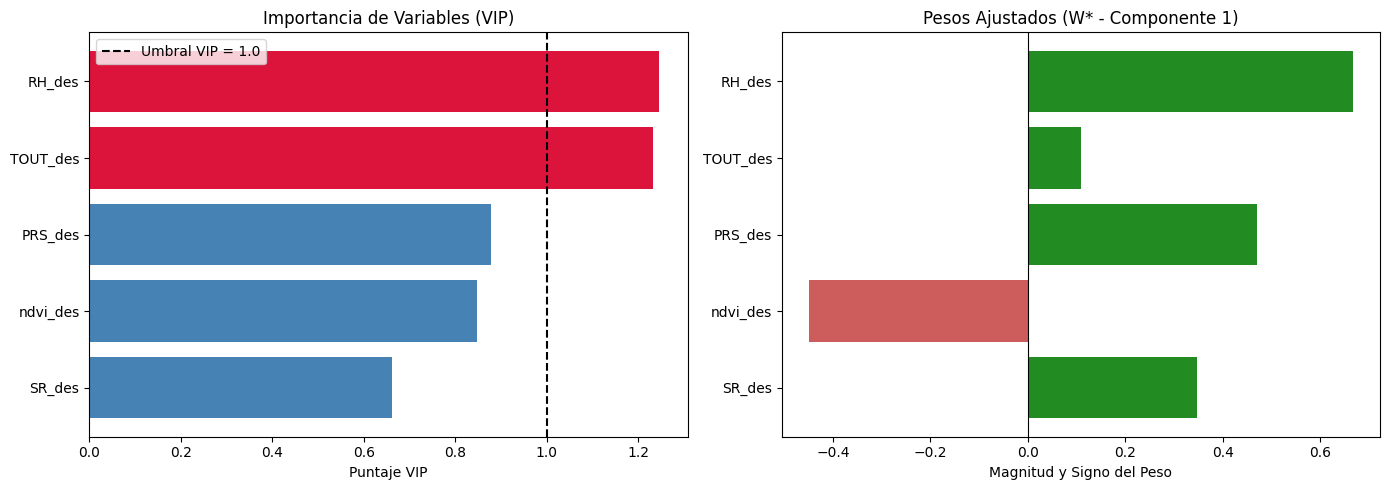

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calculate_vip(model):
    """
    Calcula el puntaje VIP (Variable Importance in Projection)
    para un objeto PLSRegression de scikit-learn.
    """
    t = model.x_scores_       # Puntuaciones de X
    w = model.x_weights_      # Pesos de X
    q = model.y_loadings_     # Cargas de Y

    p, h = w.shape            # p = número de variables, h = número de componentes
    vips = np.zeros(p)

    # Varianza explicada de Y por cada componente latente
    s = np.diag(t.T @ t @ q.T @ q)
    total_s = np.sum(s)

    for i in range(p):
        # Suma ponderada del peso al cuadrado de la variable i en cada componente
        weight_sum = np.sum(s * (w[i, :] ** 2))
        vips[i] = np.sqrt(p * weight_sum / total_s)

    return vips

# =====================================================================
# Extracción de la interpretación del modelo 'pls' previamente entrenado
# =====================================================================

# 1. Calcular VIPs
vips = calculate_vip(pls)

# 2. Obtener Coeficientes estandarizados directos
coefs = pls.coef_.ravel()

# 3. Obtener Pesos Ajustados (W*) del primer componente latente
# Nota: x_rotations_ (W*) representa la dirección de proyección en X
pesos_w_star = pls.x_rotations_[:, 0]

# 4. Consolidar en un DataFrame
df_importance = pd.DataFrame({
    'Variable_Lag': X.columns,
    'VIP': vips,
    'Peso_W1*': pesos_w_star,      # Pesos ajustados primer componente
    'Coeficiente': coefs
}).sort_values(by='VIP', ascending=False)

print("=== Importancia y Estructura de Variables (Ordenado por VIP) ===")
print(df_importance.to_string(index=False))

# 5. Visualizar los puntajes VIP y los Pesos
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Puntajes VIP
colors_vip = ['crimson' if v >= 1.0 else 'steelblue' for v in df_importance['VIP']]
ax[0].barh(df_importance['Variable_Lag'], df_importance['VIP'], color=colors_vip)
ax[0].axvline(x=1.0, color='black', linestyle='--', label='Umbral VIP = 1.0')
ax[0].invert_yaxis()
ax[0].set_title('Importancia de Variables (VIP)')
ax[0].set_xlabel('Puntaje VIP')
ax[0].legend()

# Gráfico 2: Pesos (W*)
colors_pesos = ['forestgreen' if w > 0 else 'indianred' for w in df_importance['Peso_W1*']]
ax[1].barh(df_importance['Variable_Lag'], df_importance['Peso_W1*'], color=colors_pesos)
ax[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax[1].invert_yaxis()
ax[1].set_title('Pesos Ajustados (W* - Componente 1)')
ax[1].set_xlabel('Magnitud y Signo del Peso')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression

def bootstrap_pls_significance(X, y, n_components=1, n_bootstraps=1000, alpha=0.05):
    """
    Evalúa la significancia estadística de los pesos y VIP mediante Bootstrap.
    """
    n_samples, n_features = X.shape
    vips_boot = []
    weights_boot = []

    pls = PLSRegression(n_components=n_components)

    for _ in range(n_bootstraps):
        # Remuestreo con reemplazo
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        X_resampled = X.iloc[indices] if isinstance(X, pd.DataFrame) else X[indices]
        y_resampled = y.iloc[indices] if isinstance(y, pd.Series) else y[indices]

        # Ajustar modelo
        pls.fit(X_resampled, y_resampled)

        # Guardar pesos (del primer componente)
        weights_boot.append(pls.x_weights_[:, 0])

        # Guardar VIP (usando la función previamente definida)
        vips_boot.append(calculate_vip(pls))

    vips_boot = np.array(vips_boot)
    weights_boot = np.array(weights_boot)

    # Calcular percentiles para intervalos de confianza (95%)
    lower_p = (alpha / 2) * 100
    upper_p = (1 - alpha / 2) * 100

    results = []
    feature_names = X.columns if isinstance(X, pd.DataFrame) else [f'X{i}' for i in range(n_features)]

    for i, name in enumerate(feature_names):
        # Estadísticas de Pesos
        w_mean = np.mean(weights_boot[:, i])
        w_ci_low = np.percentile(weights_boot[:, i], lower_p)
        w_ci_high = np.percentile(weights_boot[:, i], upper_p)
        w_sig = (w_ci_low > 0 and w_ci_high > 0) or (w_ci_low < 0 and w_ci_high < 0)

        # Estadísticas de VIP
        vip_mean = np.mean(vips_boot[:, i])
        vip_ci_low = np.percentile(vips_boot[:, i], lower_p)

        results.append({
            'Variable': name,
            'Peso_Medio': w_mean,
            'IC_Peso': f"[{w_ci_low:.3f}, {w_ci_high:.3f}]",
            'Peso_Significativo': "SÍ" if w_sig else "No",
            'VIP_Medio': vip_mean,
            'IC_Low_VIP': vip_ci_low,
            'VIP_Significativo (>1)': "SÍ" if vip_ci_low > 1.0 else "No"
        })

    return pd.DataFrame(results)

# Ejemplo de uso:
df_sig = bootstrap_pls_significance(X, y, n_bootstraps=1000)
print(df_sig)

   Variable  Peso_Medio          IC_Peso Peso_Significativo  VIP_Medio  \
0  ndvi_des   -0.386006  [-0.574, 0.579]                 No   0.979287   
1    SR_des    0.274745  [-0.314, 0.539]                 No   0.684739   
2    RH_des    0.574792  [-0.505, 0.778]                 No   1.386932   
3  TOUT_des    0.056415  [-0.187, 0.350]                 No   0.263124   
4   PRS_des    0.471079  [-0.480, 0.700]                 No   1.146924   

   IC_Low_VIP VIP_Significativo (>1)  
0    0.535277                     No  
1    0.131064                     No  
2    0.947068                     No  
3    0.008894                     No  
4    0.637499                     No  


## Sin datos estacionalizados

In [ ]:
NE2_limpio = NE2[['PM10','ndvi_mediana','SR','RH','TOUT','PRS']]
NE2_limpio = NE2_limpio.dropna()
X = NE2_limpio[['ndvi_mediana','SR','RH','TOUT','PRS']]
y = NE2_limpio['PM10']

In [ ]:
# PLS estándar

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# Escalar las características
scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pls = PLSRegression(n_components=2)

pls.fit(X_train, y_train)

y_pred = pls.predict(X_test)
score = r2_score(y_test, y_pred)

print(f"R-squared (R2): {score:.4f}")


R-squared (R2): 0.3034


=== Importancia y Estructura de Variables (Ordenado por VIP) ===
Variable_Lag      VIP  Peso_W1*  Coeficiente
          RH 1.559073  0.779998    -7.130316
ndvi_mediana 0.983648 -0.433471     2.028231
        TOUT 0.926593  0.272598    -6.953228
          SR 0.681839  0.276769    -5.130423
         PRS 0.527493  0.229773    -3.884101


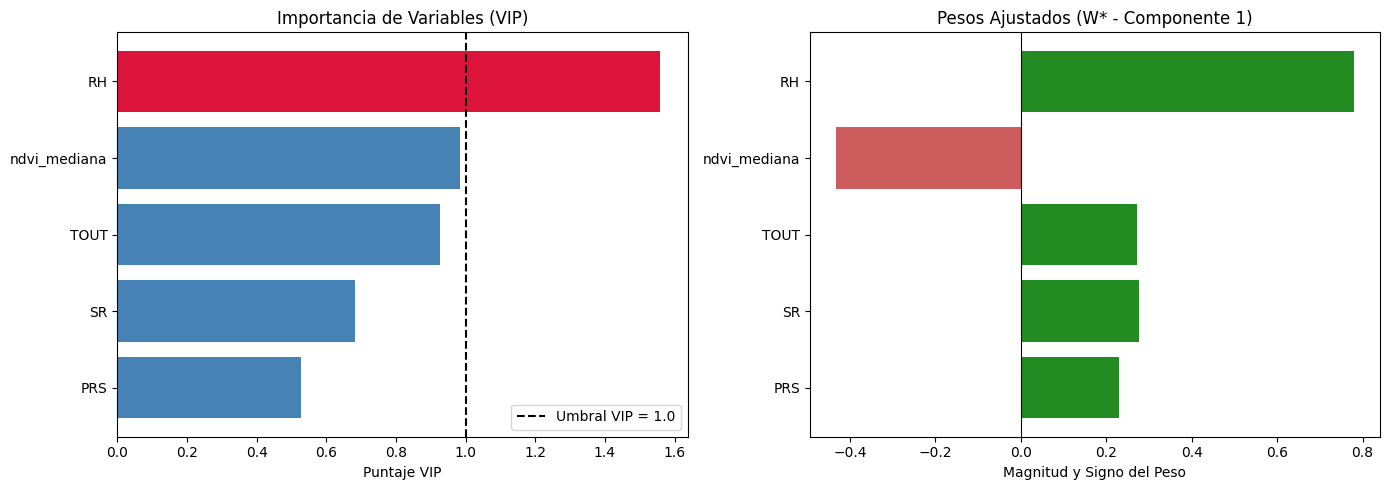

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calculate_vip(model):
    """
    Calcula el puntaje VIP (Variable Importance in Projection)
    para un objeto PLSRegression de scikit-learn.
    """
    t = model.x_scores_       # Puntuaciones de X
    w = model.x_weights_      # Pesos de X
    q = model.y_loadings_     # Cargas de Y

    p, h = w.shape            # p = número de variables, h = número de componentes
    vips = np.zeros(p)

    # Varianza explicada de Y por cada componente latente
    s = np.diag(t.T @ t @ q.T @ q)
    total_s = np.sum(s)

    for i in range(p):
        # Suma ponderada del peso al cuadrado de la variable i en cada componente
        weight_sum = np.sum(s * (w[i, :] ** 2))
        vips[i] = np.sqrt(p * weight_sum / total_s)

    return vips

# =====================================================================
# Extracción de la interpretación del modelo 'pls' previamente entrenado
# =====================================================================

# 1. Calcular VIPs
vips = calculate_vip(pls)

# 2. Obtener Coeficientes estandarizados directos
coefs = pls.coef_.ravel()

# 3. Obtener Pesos Ajustados (W*) del primer componente latente
# Nota: x_rotations_ (W*) representa la dirección de proyección en X
pesos_w_star = pls.x_rotations_[:, 0]

# 4. Consolidar en un DataFrame
df_importance = pd.DataFrame({
    'Variable_Lag': X.columns,
    'VIP': vips,
    'Peso_W1*': pesos_w_star,      # Pesos ajustados primer componente
    'Coeficiente': coefs
}).sort_values(by='VIP', ascending=False)

print("=== Importancia y Estructura de Variables (Ordenado por VIP) ===")
print(df_importance.to_string(index=False))

# 5. Visualizar los puntajes VIP y los Pesos
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Puntajes VIP
colors_vip = ['crimson' if v >= 1.0 else 'steelblue' for v in df_importance['VIP']]
ax[0].barh(df_importance['Variable_Lag'], df_importance['VIP'], color=colors_vip)
ax[0].axvline(x=1.0, color='black', linestyle='--', label='Umbral VIP = 1.0')
ax[0].invert_yaxis()
ax[0].set_title('Importancia de Variables (VIP)')
ax[0].set_xlabel('Puntaje VIP')
ax[0].legend()

# Gráfico 2: Pesos (W*)
colors_pesos = ['forestgreen' if w > 0 else 'indianred' for w in df_importance['Peso_W1*']]
ax[1].barh(df_importance['Variable_Lag'], df_importance['Peso_W1*'], color=colors_pesos)
ax[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax[1].invert_yaxis()
ax[1].set_title('Pesos Ajustados (W* - Componente 1)')
ax[1].set_xlabel('Magnitud y Signo del Peso')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression

def bootstrap_pls_significance(X, y, n_components=1, n_bootstraps=1000, alpha=0.05):
    """
    Evalúa la significancia estadística de los pesos y VIP mediante Bootstrap.
    """
    n_samples, n_features = X.shape
    vips_boot = []
    weights_boot = []

    pls = PLSRegression(n_components=n_components)

    for _ in range(n_bootstraps):
        # Remuestreo con reemplazo
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        X_resampled = X.iloc[indices] if isinstance(X, pd.DataFrame) else X[indices]
        y_resampled = y.iloc[indices] if isinstance(y, pd.Series) else y[indices]

        # Ajustar modelo
        pls.fit(X_resampled, y_resampled)

        # Guardar pesos (del primer componente)
        weights_boot.append(pls.x_weights_[:, 0])

        # Guardar VIP (usando la función previamente definida)
        vips_boot.append(calculate_vip(pls))

    vips_boot = np.array(vips_boot)
    weights_boot = np.array(weights_boot)

    # Calcular percentiles para intervalos de confianza (95%)
    lower_p = (alpha / 2) * 100
    upper_p = (1 - alpha / 2) * 100

    results = []
    feature_names = X.columns if isinstance(X, pd.DataFrame) else [f'X{i}' for i in range(n_features)]

    for i, name in enumerate(feature_names):
        # Estadísticas de Pesos
        w_mean = np.mean(weights_boot[:, i])
        w_ci_low = np.percentile(weights_boot[:, i], lower_p)
        w_ci_high = np.percentile(weights_boot[:, i], upper_p)
        w_sig = (w_ci_low > 0 and w_ci_high > 0) or (w_ci_low < 0 and w_ci_high < 0)

        # Estadísticas de VIP
        vip_mean = np.mean(vips_boot[:, i])
        vip_ci_low = np.percentile(vips_boot[:, i], lower_p)

        results.append({
            'Variable': name,
            'Peso_Medio': w_mean,
            'IC_Peso': f"[{w_ci_low:.3f}, {w_ci_high:.3f}]",
            'Peso_Significativo': "SÍ" if w_sig else "No",
            'VIP_Medio': vip_mean,
            'IC_Low_VIP': vip_ci_low,
            'VIP_Significativo (>1)': "SÍ" if vip_ci_low > 1.0 else "No"
        })

    return pd.DataFrame(results)

# Ejemplo de uso:
df_sig = bootstrap_pls_significance(X, y, n_bootstraps=1000)
print(df_sig)

       Variable  Peso_Medio           IC_Peso Peso_Significativo  VIP_Medio  \
0  ndvi_mediana   -0.399012  [-0.555, -0.219]                 SÍ   0.903372   
1            SR    0.251523    [0.077, 0.441]                 SÍ   0.568221   
2            RH    0.762970    [0.644, 0.874]                 SÍ   1.716675   
3          TOUT    0.176502   [-0.090, 0.446]                 No   0.420207   
4           PRS    0.307579    [0.036, 0.548]                 SÍ   0.697684   

   IC_Low_VIP VIP_Significativo (>1)  
0    0.508556                     No  
1    0.184957                     No  
2    1.440883                     SÍ  
3    0.016259                     No  
4    0.129835                     No  


In [ ]:
NE3_limpio = NE3[['PM10','ndvi_mediana','RH','TOUT','PRS','SR']]
NE3_limpio = NE3_limpio.dropna()
X = NE3_limpio[['ndvi_mediana','RH','TOUT','PRS','SR']]
y = NE3_limpio['PM10']

In [ ]:
# PLS estándar

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# Escalar las características
scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pls = PLSRegression(n_components=2)

pls.fit(X_train, y_train)

y_pred = pls.predict(X_test)
score = r2_score(y_test, y_pred)

print(f"R-squared (R2): {score:.4f}")


R-squared (R2): 0.4588


=== Importancia y Estructura de Variables (Ordenado por VIP) ===
Variable_Lag      VIP  Peso_W1*  Coeficiente
          RH 1.740618  0.868921    -7.158603
        TOUT 0.980084  0.157928    -4.408168
         PRS 0.862254  0.427373    -3.333409
ndvi_mediana 0.385818 -0.191846     1.818240
          SR 0.342560  0.024144    -1.318308


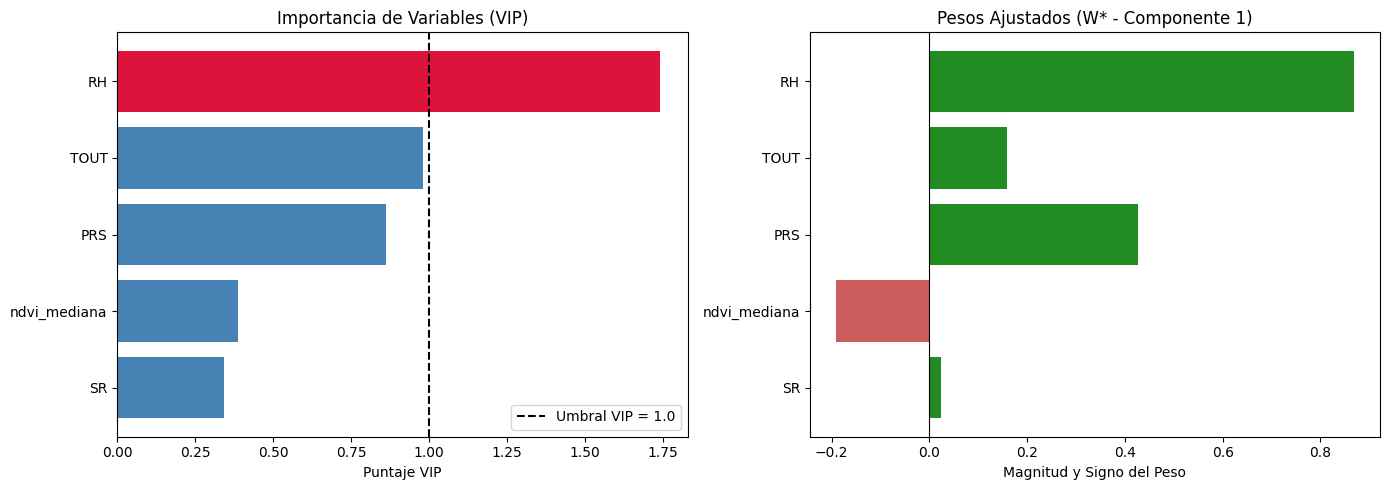

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calculate_vip(model):
    """
    Calcula el puntaje VIP (Variable Importance in Projection)
    para un objeto PLSRegression de scikit-learn.
    """
    t = model.x_scores_       # Puntuaciones de X
    w = model.x_weights_      # Pesos de X
    q = model.y_loadings_     # Cargas de Y

    p, h = w.shape            # p = número de variables, h = número de componentes
    vips = np.zeros(p)

    # Varianza explicada de Y por cada componente latente
    s = np.diag(t.T @ t @ q.T @ q)
    total_s = np.sum(s)

    for i in range(p):
        # Suma ponderada del peso al cuadrado de la variable i en cada componente
        weight_sum = np.sum(s * (w[i, :] ** 2))
        vips[i] = np.sqrt(p * weight_sum / total_s)

    return vips

# =====================================================================
# Extracción de la interpretación del modelo 'pls' previamente entrenado
# =====================================================================

# 1. Calcular VIPs
vips = calculate_vip(pls)

# 2. Obtener Coeficientes estandarizados directos
coefs = pls.coef_.ravel()

# 3. Obtener Pesos Ajustados (W*) del primer componente latente
# Nota: x_rotations_ (W*) representa la dirección de proyección en X
pesos_w_star = pls.x_rotations_[:, 0]

# 4. Consolidar en un DataFrame
df_importance = pd.DataFrame({
    'Variable_Lag': X.columns,
    'VIP': vips,
    'Peso_W1*': pesos_w_star,      # Pesos ajustados primer componente
    'Coeficiente': coefs
}).sort_values(by='VIP', ascending=False)

print("=== Importancia y Estructura de Variables (Ordenado por VIP) ===")
print(df_importance.to_string(index=False))

# 5. Visualizar los puntajes VIP y los Pesos
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Puntajes VIP
colors_vip = ['crimson' if v >= 1.0 else 'steelblue' for v in df_importance['VIP']]
ax[0].barh(df_importance['Variable_Lag'], df_importance['VIP'], color=colors_vip)
ax[0].axvline(x=1.0, color='black', linestyle='--', label='Umbral VIP = 1.0')
ax[0].invert_yaxis()
ax[0].set_title('Importancia de Variables (VIP)')
ax[0].set_xlabel('Puntaje VIP')
ax[0].legend()

# Gráfico 2: Pesos (W*)
colors_pesos = ['forestgreen' if w > 0 else 'indianred' for w in df_importance['Peso_W1*']]
ax[1].barh(df_importance['Variable_Lag'], df_importance['Peso_W1*'], color=colors_pesos)
ax[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax[1].invert_yaxis()
ax[1].set_title('Pesos Ajustados (W* - Componente 1)')
ax[1].set_xlabel('Magnitud y Signo del Peso')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression

def bootstrap_pls_significance(X, y, n_components=1, n_bootstraps=1000, alpha=0.05):
    """
    Evalúa la significancia estadística de los pesos y VIP mediante Bootstrap.
    """
    n_samples, n_features = X.shape
    vips_boot = []
    weights_boot = []

    pls = PLSRegression(n_components=n_components)

    for _ in range(n_bootstraps):
        # Remuestreo con reemplazo
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        X_resampled = X.iloc[indices] if isinstance(X, pd.DataFrame) else X[indices]
        y_resampled = y.iloc[indices] if isinstance(y, pd.Series) else y[indices]

        # Ajustar modelo
        pls.fit(X_resampled, y_resampled)

        # Guardar pesos (del primer componente)
        weights_boot.append(pls.x_weights_[:, 0])

        # Guardar VIP (usando la función previamente definida)
        vips_boot.append(calculate_vip(pls))

    vips_boot = np.array(vips_boot)
    weights_boot = np.array(weights_boot)

    # Calcular percentiles para intervalos de confianza (95%)
    lower_p = (alpha / 2) * 100
    upper_p = (1 - alpha / 2) * 100

    results = []
    feature_names = X.columns if isinstance(X, pd.DataFrame) else [f'X{i}' for i in range(n_features)]

    for i, name in enumerate(feature_names):
        # Estadísticas de Pesos
        w_mean = np.mean(weights_boot[:, i])
        w_ci_low = np.percentile(weights_boot[:, i], lower_p)
        w_ci_high = np.percentile(weights_boot[:, i], upper_p)
        w_sig = (w_ci_low > 0 and w_ci_high > 0) or (w_ci_low < 0 and w_ci_high < 0)

        # Estadísticas de VIP
        vip_mean = np.mean(vips_boot[:, i])
        vip_ci_low = np.percentile(vips_boot[:, i], lower_p)

        results.append({
            'Variable': name,
            'Peso_Medio': w_mean,
            'IC_Peso': f"[{w_ci_low:.3f}, {w_ci_high:.3f}]",
            'Peso_Significativo': "SÍ" if w_sig else "No",
            'VIP_Medio': vip_mean,
            'IC_Low_VIP': vip_ci_low,
            'VIP_Significativo (>1)': "SÍ" if vip_ci_low > 1.0 else "No"
        })

    return pd.DataFrame(results)

# Ejemplo de uso:
df_sig = bootstrap_pls_significance(X, y, n_bootstraps=1000)
print(df_sig)

       Variable  Peso_Medio          IC_Peso Peso_Significativo  VIP_Medio  \
0  ndvi_mediana   -0.055895  [-0.267, 0.150]                 No   0.213995   
1            RH    0.877713   [0.800, 0.940]                 SÍ   1.962627   
2          TOUT    0.131611  [-0.093, 0.364]                 No   0.329975   
3           PRS    0.412178   [0.197, 0.581]                 SÍ   0.921659   
4            SR   -0.001098  [-0.127, 0.092]                 No   0.093867   

   IC_Low_VIP VIP_Significativo (>1)  
0    0.012752                     No  
1    1.788947                     SÍ  
2    0.015345                     No  
3    0.440123                     No  
4    0.003184                     No  
